**Load Libraries + Dataset**

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/student_productivity_distraction_dataset_20000.csv')

print(df.shape)
df.head()

(20000, 18)


,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90


**Understand Columns**

In [43]:
df.info()
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  focus_score  

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
unique,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,9640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,10000.500000,23.00745,NaN,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,NaN,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,NaN,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,NaN,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,NaN,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,NaN,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500


**Check missing values**

In [44]:
df.isnull().sum().sort_values(ascending=False)

student_id               0
age                      0
final_grade              0
focus_score              0
stress_level             0
attendance_percentage    0
assignments_completed    0
exercise_minutes         0
coffee_intake_mg         0
breaks_per_day           0
gaming_hours             0
youtube_hours            0
social_media_hours       0
phone_usage_hours        0
sleep_hours              0
study_hours_per_day      0
gender                   0
productivity_score       0
dtype: int64

**Remove Duplicates (if any)**

In [45]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


**Detect Column Types**

In [46]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: Index(['student_id', 'age', 'study_hours_per_day', 'sleep_hours',
       'phone_usage_hours', 'social_media_hours', 'youtube_hours',
       'gaming_hours', 'breaks_per_day', 'coffee_intake_mg',
       'exercise_minutes', 'assignments_completed', 'attendance_percentage',
       'stress_level', 'focus_score', 'final_grade', 'productivity_score'],
      dtype='str')
Categorical: Index(['gender'], dtype='str')


C:\Users\Aditya Garg\AppData\Local\Temp\ipykernel_40068\1936651878.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


**PREPROCESSING**

**Fill Missing Values**

In [47]:
# Numeric → median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Categorical → mode
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

**Encode Categorical Columns**

In [48]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

**Outlier Check**

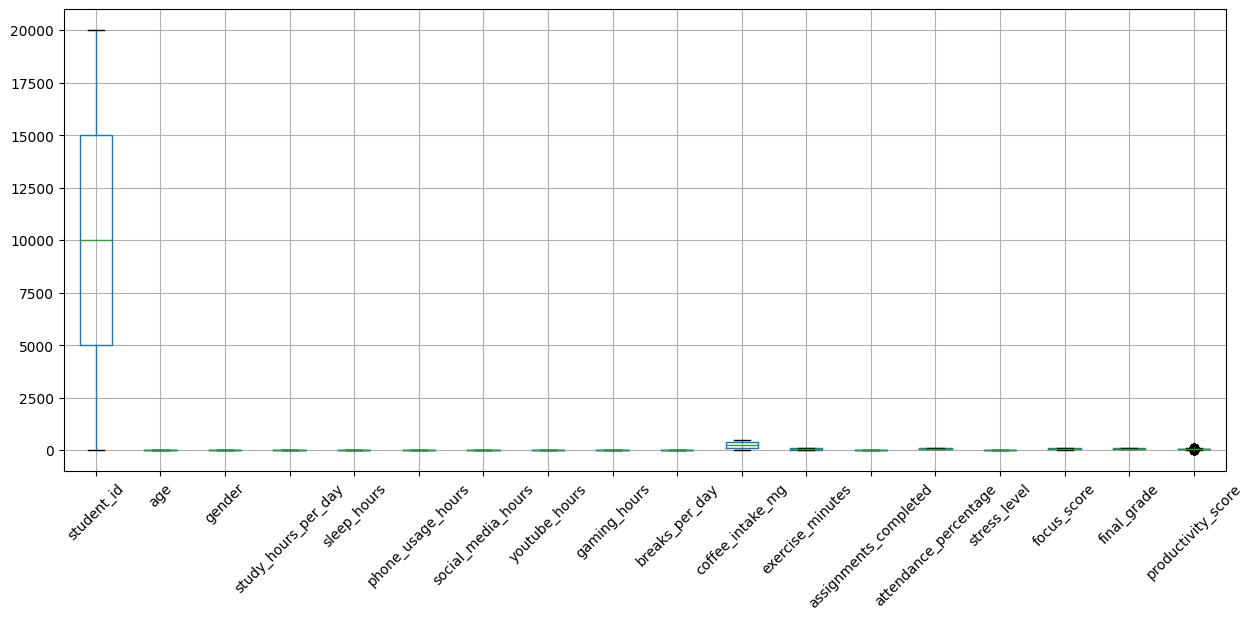

In [49]:
plt.figure(figsize=(15,6))
df.boxplot(rot=45)
plt.show()

**Optional Outlier Treatment**

In [50]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.clip(df[col], lower, upper)

**CORRELATION CHECK**

**Heatmap**

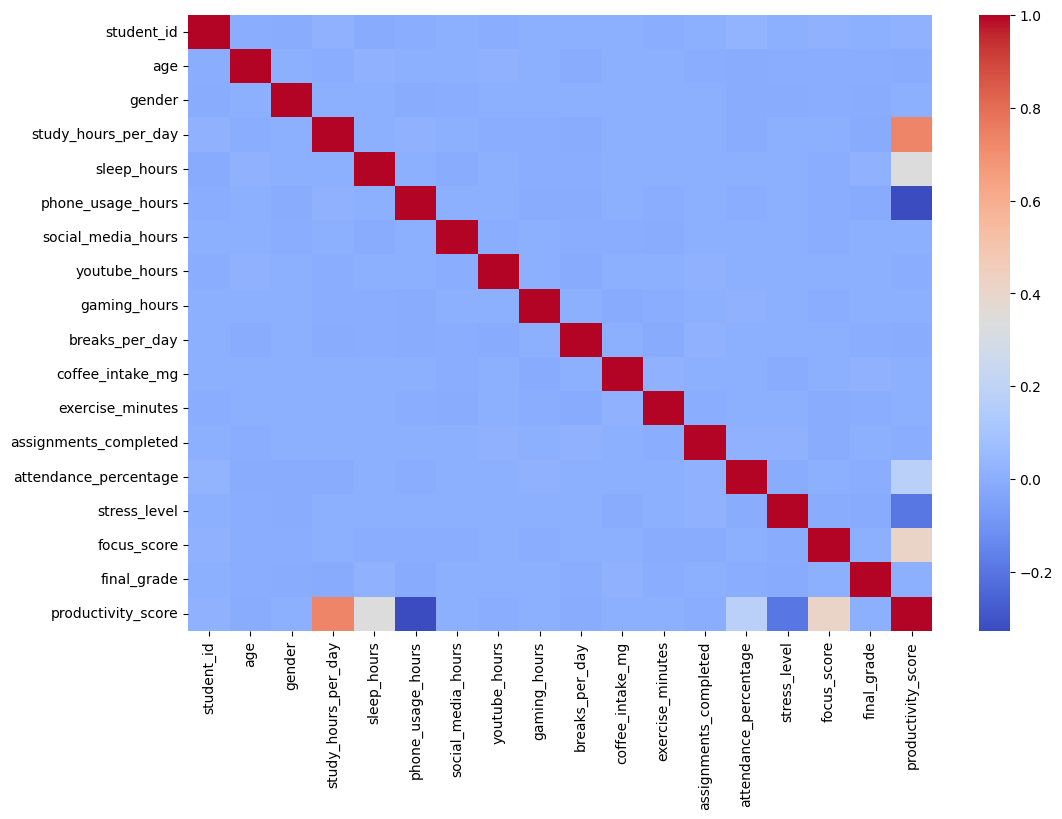

In [51]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

**Productivity Correlation Only**

In [52]:
df.corr(numeric_only=True)['productivity_score'].sort_values(ascending=False)

productivity_score       1.000000
study_hours_per_day      0.732844
focus_score              0.411340
sleep_hours              0.340857
attendance_percentage    0.176062
student_id               0.012626
coffee_intake_mg         0.010191
gender                   0.003725
exercise_minutes         0.002899
final_grade              0.001931
social_media_hours       0.001279
gaming_hours             0.000733
youtube_hours           -0.000241
assignments_completed   -0.001707
age                     -0.005461
breaks_per_day          -0.005854
stress_level            -0.197051
phone_usage_hours       -0.326614
Name: productivity_score, dtype: float64

**Column Names**

In [53]:
df.columns.tolist()

['student_id',
 'age',
 'gender',
 'study_hours_per_day',
 'sleep_hours',
 'phone_usage_hours',
 'social_media_hours',
 'youtube_hours',
 'gaming_hours',
 'breaks_per_day',
 'coffee_intake_mg',
 'exercise_minutes',
 'assignments_completed',
 'attendance_percentage',
 'stress_level',
 'focus_score',
 'final_grade',
 'productivity_score']

**Export Processsed Data**

In [54]:
df.to_csv("../data/processed_data.csv", index=False)